In [ ]:
'''
實務!!!

如何在不增加n的情況下，降低variance

9.1 

𝑍∼Unif(0,1)，則 1−Z 也服從 Uniform 分布，

強制抽負相關的


9.2 control variate

E[X] = theta

X + c(y - uy) = theta (不變)


但variance 下降!!

var(x + cy) = var(x) (原本) - [cov(x,y)]**2 / var(y)

但c值，用估的



'''

In [ ]:
'''

9.3 condition

變異數拆解  var(x) = E[var(x|y)] (大於0) + var(E[x|y])



用var(E[x|y]) 較優， 且 E(E[x|y]) = theta(相同)


ex : compound poisson

s = sigma xi (n~ poisson)


we want P(sigma xi  > C)  

I = 1 (sigma xi  > C) else 0 (傳統)


condition M = min number(相加大於C)


I = 1  等價(若且為若) N >= M

E[I | M] == P(N >= M | M) ==>  P(N >= M) 無憶


抽100次取平均 !
'''

In [ ]:
'''
分層抽樣 : 每區都要抽到


E[X] = sigma E[x| yi] Pj(region prob)


var(x) - var(e) = var(E[x|y]) / n

'''

In [ ]:
'''
Importance sampling


θ==∫h(x)f(x)dx (難啊)

改從 g(x) 抽樣(好生)，最後對原分布進行加權，以此得出theta。


ex :

x ~ N(0, 1)

求 p(X > 10 ) = sigma(I)。(根本抽不到啊)

改從 x ~ N(10, 1)抽。

p(X > 10 ) = sigma(I) / N * (修正函數)


當g(x)選得夠好，variance 下降
'''

True θ = P(X > 5): 2.866515719235352e-07
Crude MC estimate: 0.0
Crude MC variance: 0.0
Importance Sampling estimate: 2.860449859837819e-07
Importance Sampling variance: 4.646866015963107e-18


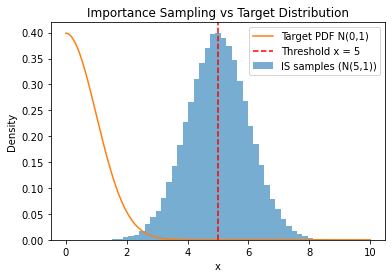

In [1]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

# 目標：估計 P(X > 5) where X ~ N(0,1)
true_theta = 1 - norm.cdf(5)

# 傳統 Monte Carlo 模擬
n = 100000
np.random.seed(42)
samples_crude = np.random.normal(loc=0, scale=1, size=n)
indicator_crude = (samples_crude > 5).astype(float)
theta_crude = np.mean(indicator_crude)
var_crude = np.var(indicator_crude) / n

# Importance Sampling：從 N(5,1) 抽樣
samples_is = np.random.normal(loc=5, scale=1, size=n)
# likelihood ratio f(x)/g(x)
weights = norm.pdf(samples_is, loc=0, scale=1) / norm.pdf(samples_is, loc=5, scale=1)
indicator_is = (samples_is > 5).astype(float)
theta_is = np.mean(weights * indicator_is)
var_is = np.var(weights * indicator_is) / n

# 顯示結果
print("True θ = P(X > 5):", true_theta)
print("Crude MC estimate:", theta_crude)
print("Crude MC variance:", var_crude)
print("Importance Sampling estimate:", theta_is)
print("Importance Sampling variance:", var_is)

# 可選：視覺化 proposal sampling 的樣本位置
plt.hist(samples_is, bins=50, alpha=0.6, density=True, label="IS samples (N(5,1))")
x = np.linspace(0, 10, 1000)
plt.plot(x, norm.pdf(x), label="Target PDF N(0,1)")
plt.axvline(5, color='red', linestyle='--', label="Threshold x = 5")
plt.legend()
plt.title("Importance Sampling vs Target Distribution")
plt.xlabel("x")
plt.ylabel("Density")
plt.show()
